# Waco BSR — Thermal Model Performance Review

Diagnoses the warm bias in pool temperature forecasts.  
Real-world max: **~91-95°F (32.8°C)** even at 108°F (40.6°C) air temp.

**Before running:** pull the DB from EC2:
```bash
scp ec2-user@<EC2_HOST>:/var/www/html/data/wave_pool_weather.db ../data/wave_pool_weather.db
```

**Requires:** `pip install matplotlib numpy`

In [1]:
import sqlite3
import json
import math
import os
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

# ── DB path ──────────────────────────────────────────────────────────────────
DB_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'wave_pool_weather.db')
if not os.path.exists(DB_PATH):
    # Fallback: look in current working directory's parent tree
    DB_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'wave_pool_weather.db'))

print(f'DB path: {DB_PATH}')
print(f'DB exists: {os.path.exists(DB_PATH)}')

# Real-world cap
REAL_MAX_F = 91.0 # maybe?
REAL_MAX_C = (REAL_MAX_F - 32) * 5 / 9  # 32.78°C

def c_to_f(c):
    return c * 9 / 5 + 32

DB path: /Users/dylanelliott/Documents/GitHub/wave_pool_weather/data/wave_pool_weather.db
DB exists: True


In [2]:
# ── Query all Waco forecast data ──────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
cur = conn.cursor()

cur.execute("SELECT id FROM locations WHERE name = 'Waco'")
row = cur.fetchone()
assert row, "Waco not found in locations table — is the DB correct?"
waco_id = row['id']
print(f'Waco location_id: {waco_id}')

cur.execute("""
    SELECT
        pt.date,
        pt.temp            AS pool_temp_C,
        pt.morning_temp_C,
        pt.afternoon_temp_C,
        pt.heat_fluxes,
        at.temp            AS air_temp_C,
        at.humidity,
        at.wind_speed,
        at.solar_radiation
    FROM pool_temps pt
    JOIN air_temps at ON pt.location_id = at.location_id AND pt.date = at.date
    WHERE pt.location_id = ?
    ORDER BY pt.date
""", (waco_id,))

rows = cur.fetchall()
conn.close()
print(f'Rows fetched: {len(rows)}')
if rows:
    print(f'Date range: {rows[0]["date"]} → {rows[-1]["date"]}')

Waco location_id: 1
Rows fetched: 94
Date range: 2026-04-06 → 2026-07-08


In [3]:
# ── Parse rows ────────────────────────────────────────────────────────────────
dates       = []
pool_F      = []
air_F       = []
solar       = []
humidity    = []
wind_speed  = []
fluxes_list = []  # list of dicts

for r in rows:
    if r['pool_temp_C'] is None or r['air_temp_C'] is None:
        continue
    dates.append(datetime.strptime(r['date'], '%Y-%m-%d'))
    pool_F.append(c_to_f(r['pool_temp_C']))
    air_F.append(c_to_f(r['air_temp_C']))
    val = r['solar_radiation']
    solar.append(float(val) if val is not None else 0.0)
    humidity.append(r['humidity'] or 50.0)
    wind_speed.append(r['wind_speed'] or 3.0)
    if r['heat_fluxes']:
        fluxes_list.append(json.loads(r['heat_fluxes']))
    else:
        fluxes_list.append({})

dates    = np.array(dates)
pool_F   = np.array(pool_F)
air_F    = np.array(air_F)
solar    = np.array(solar)
humidity = np.array(humidity)
wind_speed = np.array(wind_speed)

print(f'Parsed {len(dates)} rows')
print(f'Pool temp range: {pool_F.min():.1f}–{pool_F.max():.1f}°F')
print(f'Air temp range:  {air_F.min():.1f}–{air_F.max():.1f}°F')
print(f'Days pool > 91°F cap: {(pool_F > REAL_MAX_F).sum()}')

Parsed 94 rows
Pool temp range: 63.8–173.3°F
Air temp range:  57.0–174.2°F
Days pool > 91°F cap: 25


## Plot 1 — Temperature Bias Time Series
Shows predicted pool temp vs. air temp vs. the real-world 91°F cap.

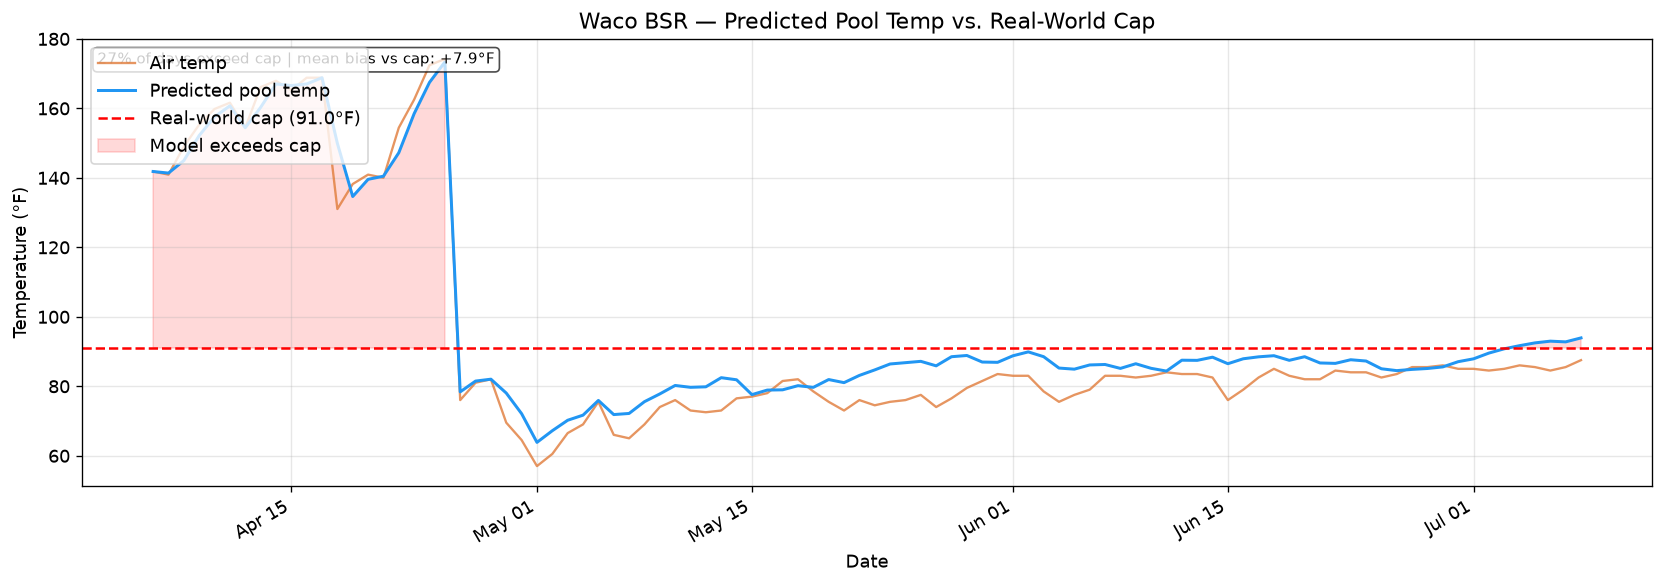

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates, air_F,  color='#e07b39', linewidth=1.4, label='Air temp', alpha=0.8)
ax.plot(dates, pool_F, color='#2196f3', linewidth=1.8, label='Predicted pool temp')
ax.axhline(REAL_MAX_F, color='red', linestyle='--', linewidth=1.5, label=f'Real-world cap ({REAL_MAX_F}°F)')

# Shade region above cap
ax.fill_between(dates, REAL_MAX_F, pool_F, where=(pool_F > REAL_MAX_F),
                color='red', alpha=0.15, label='Model exceeds cap')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°F)')
ax.set_title('Waco BSR — Predicted Pool Temp vs. Real-World Cap')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.grid(True, alpha=0.3)

pct_over = 100 * (pool_F > REAL_MAX_F).mean()
mean_bias = pool_F.mean() - REAL_MAX_F
ax.text(0.01, 0.97, f'{pct_over:.0f}% of days exceed cap | mean bias vs cap: {mean_bias:+.1f}°F',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

## Plot 2 — Heat Flux Component Breakdown
Stacked area showing which flux term dominates.  
High bias = Q_solar >> |Q_evap|.

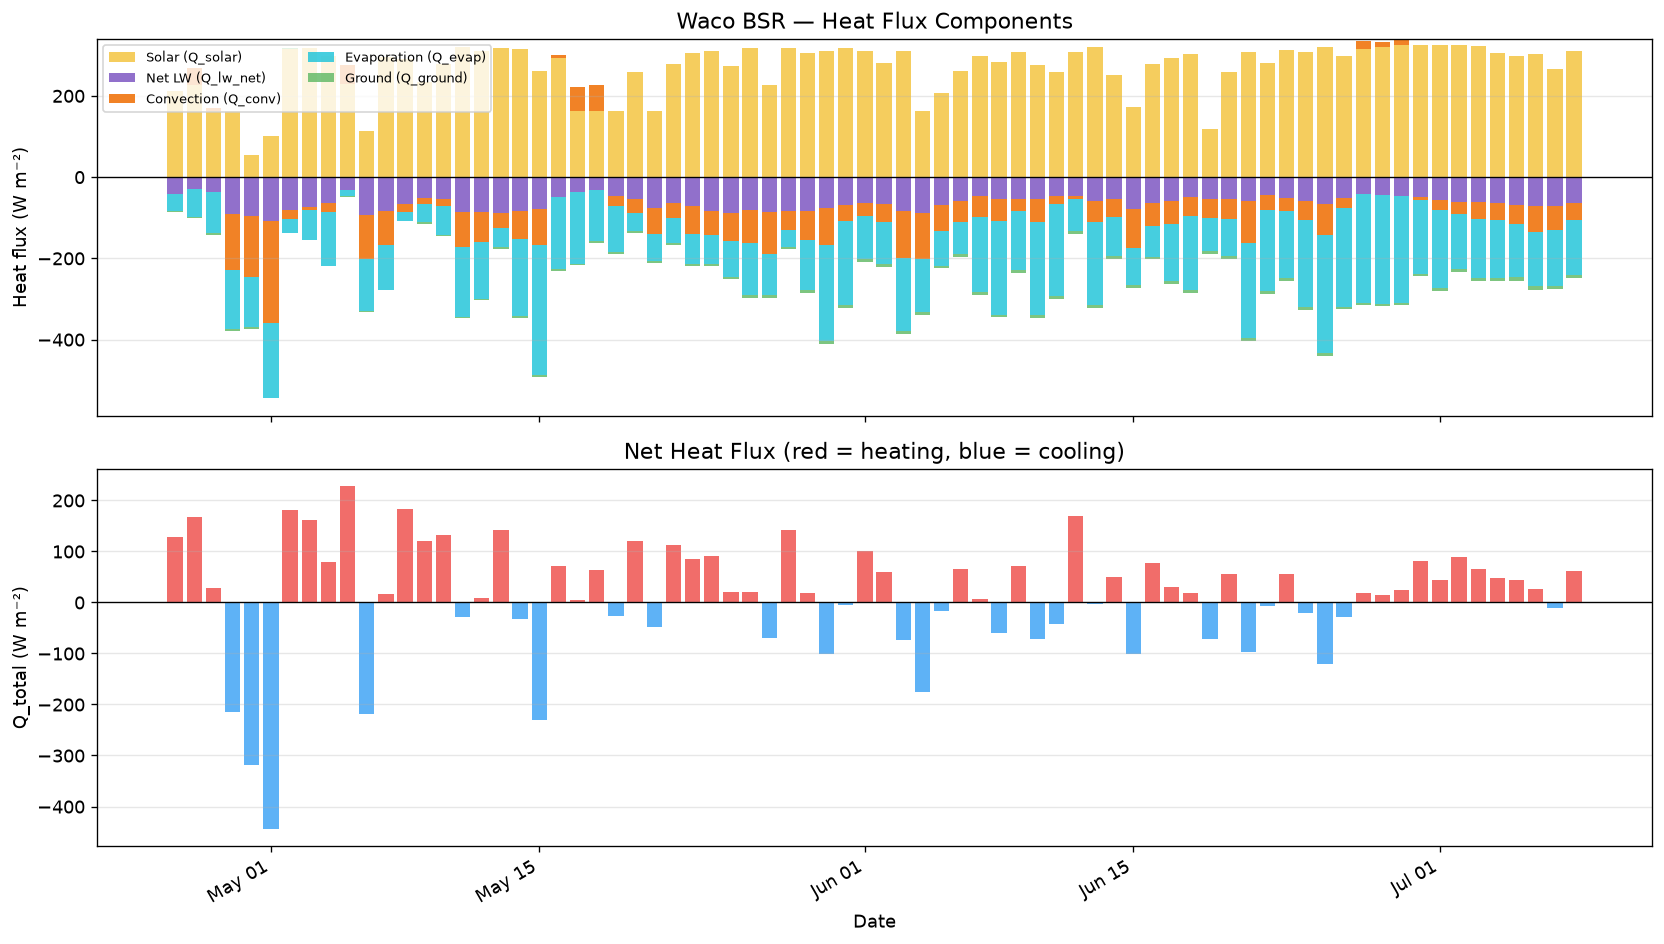

Mean Q_solar:  +267.7 W/m²
Mean Q_evap:   -138.1 W/m²
Mean |evap/solar| ratio: 0.56


In [5]:
flux_keys = ['Q_solar_Wm2', 'Q_lw_net_Wm2', 'Q_conv_Wm2', 'Q_evap_Wm2', 'Q_ground_Wm2']
flux_labels = ['Solar (Q_solar)', 'Net LW (Q_lw_net)', 'Convection (Q_conv)',
               'Evaporation (Q_evap)', 'Ground (Q_ground)']
flux_colors = ['#f4c542', '#7e57c2', '#ef6c00', '#26c6da', '#66bb6a']

flux_data = {k: [] for k in flux_keys}
valid_dates = []

for i, f in enumerate(fluxes_list):
    if not f:
        continue
    valid_dates.append(dates[i])
    for k in flux_keys:
        flux_data[k].append(f.get(k, 0.0))

if not valid_dates:
    print('No heat_fluxes JSON data in DB — this plot requires the full DB, not export files.')
else:
    valid_dates = np.array(valid_dates)
    arrays = [np.array(flux_data[k]) for k in flux_keys]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Top: positive vs negative fluxes
    pos = np.zeros(len(valid_dates))
    neg = np.zeros(len(valid_dates))
    for arr, label, color in zip(arrays, flux_labels, flux_colors):
        pos_part = np.where(arr > 0, arr, 0)
        neg_part = np.where(arr < 0, arr, 0)
        ax1.bar(valid_dates, pos_part, bottom=pos, label=label, color=color, alpha=0.85, width=0.8)
        ax1.bar(valid_dates, neg_part, bottom=neg, color=color, alpha=0.85, width=0.8)
        pos += pos_part
        neg += neg_part

    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.set_ylabel('Heat flux (W m⁻²)')
    ax1.set_title('Waco BSR — Heat Flux Components')
    ax1.legend(loc='upper left', fontsize=8, ncol=2)
    ax1.grid(True, alpha=0.3, axis='y')

    # Bottom: Q_total (net)
    q_total = np.array([f.get('Q_total_Wm2', 0.0) for f in fluxes_list if f])
    ax2.bar(valid_dates, q_total, color=np.where(q_total > 0, '#ef5350', '#42a5f5'),
            alpha=0.85, width=0.8, label='Q_total')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Q_total (W m⁻²)')
    ax2.set_xlabel('Date')
    ax2.set_title('Net Heat Flux (red = heating, blue = cooling)')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.grid(True, alpha=0.3, axis='y')

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # Summary stats
    q_solar = np.array(flux_data['Q_solar_Wm2'])
    q_evap  = np.array(flux_data['Q_evap_Wm2'])
    print(f'Mean Q_solar:  {q_solar.mean():+.1f} W/m²')
    print(f'Mean Q_evap:   {q_evap.mean():+.1f} W/m²')
    print(f'Mean |evap/solar| ratio: {np.abs(q_evap / np.where(q_solar == 0, np.nan, q_solar)).mean():.2f}')

## Plot 3 — Predicted Pool Temp vs. Air Temp Scatter
Color = solar radiation. Red dashed line = 91°F cap.

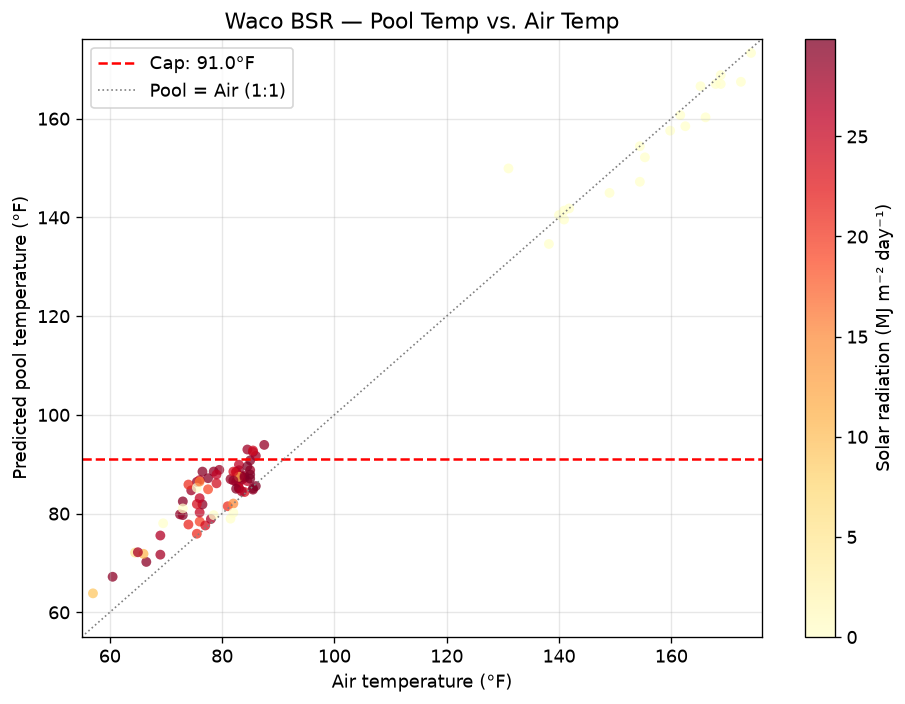

Days where air > 95°F AND pool > 91°F: 20


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(air_F, pool_F, c=solar, cmap='YlOrRd', s=35, alpha=0.75,
                vmin=solar.min(), vmax=solar.max(), edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Solar radiation (MJ m⁻² day⁻¹)')

ax.axhline(REAL_MAX_F, color='red', linestyle='--', linewidth=1.5, label=f'Cap: {REAL_MAX_F}°F')

# 1:1 line
lim = [min(air_F.min(), pool_F.min()) - 2, max(air_F.max(), pool_F.max()) + 2]
ax.plot(lim, lim, color='gray', linestyle=':', linewidth=1, label='Pool = Air (1:1)')
ax.set_xlim(lim)
ax.set_ylim(lim)

ax.set_xlabel('Air temperature (°F)')
ax.set_ylabel('Predicted pool temperature (°F)')
ax.set_title('Waco BSR — Pool Temp vs. Air Temp')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Count days where both air > 95°F and pool > 91°F
hot_days = (air_F > 95) & (pool_F > REAL_MAX_F)
print(f'Days where air > 95°F AND pool > 91°F: {hot_days.sum()}')

## Plot 4 — Parameter Sensitivity Analysis
Finds which parameter change brings steady-state pool temp to ≤91°F at 105°F air.

Steady state = run the model for 30 days until temperature stabilizes.

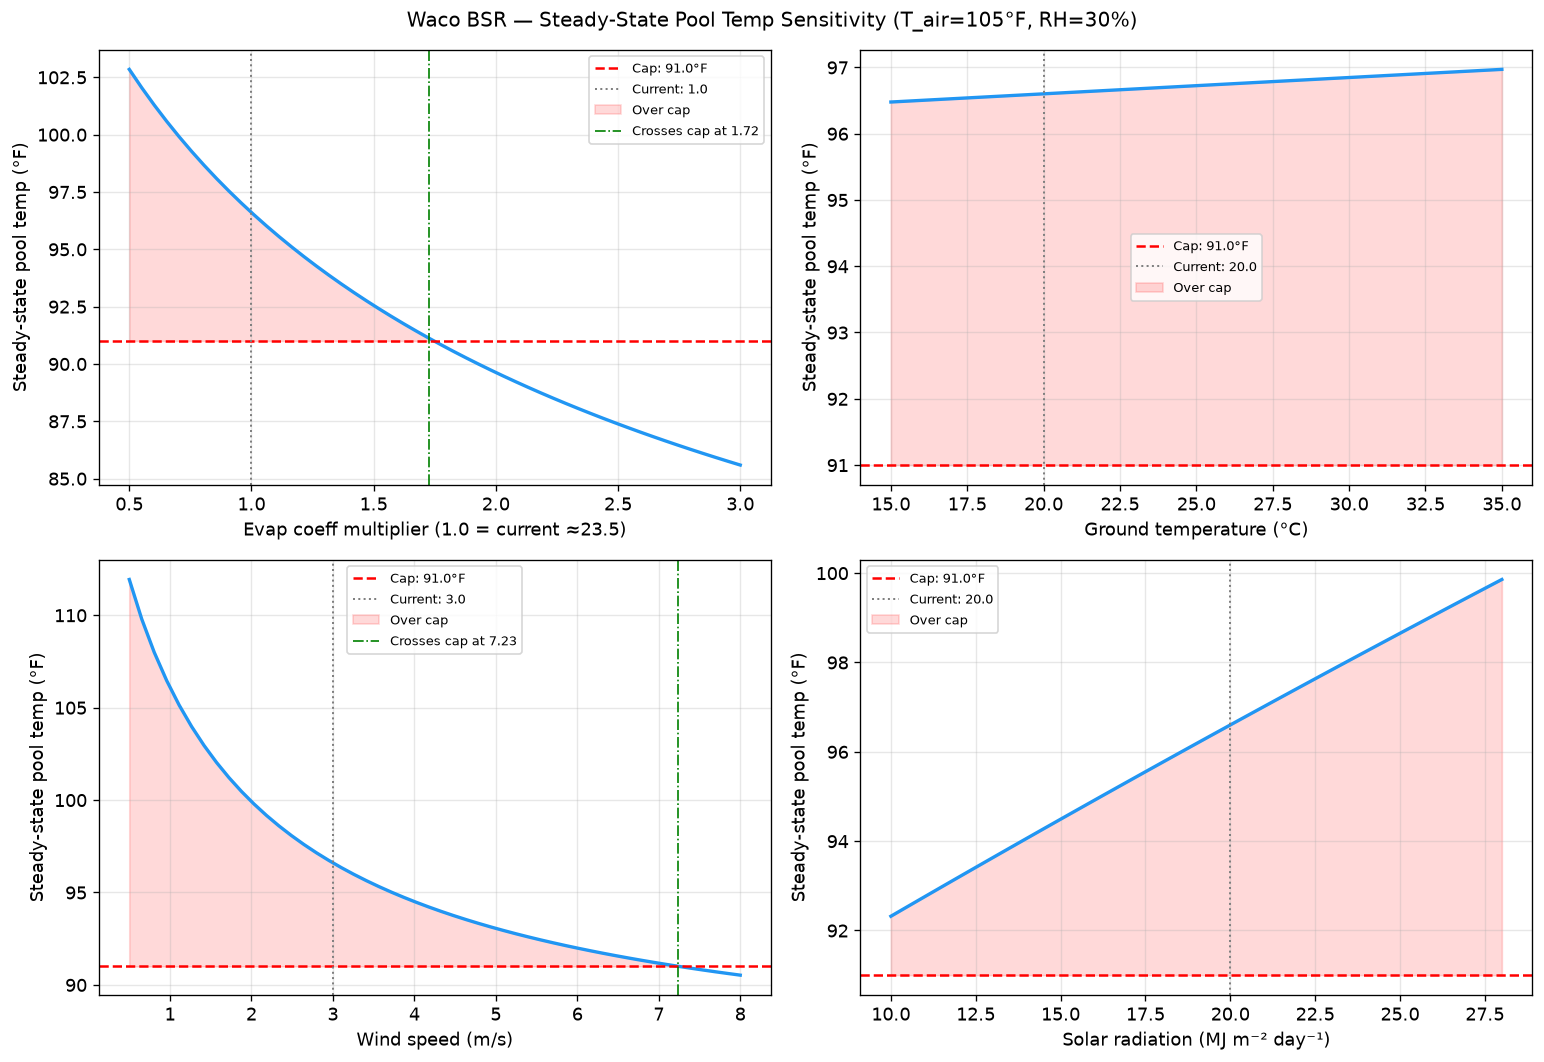

In [7]:
# ── Minimal model reimplementation for sensitivity sweeps ─────────────────────
SIGMA_SB      = 5.67e-8
EPSILON_WATER = 0.97
ALBEDO_WATER  = 0.06
RHO_WATER     = 1000.0
CP_WATER      = 4186.0
L_VAP         = 2.45e6
K_CONCRETE    = 1.4
L_CONCRETE_M  = 0.3048
K_SOIL_WACO   = 1.5
SOIL_DEPTH_M  = 2.0

def sat_vp(T_C):
    return 0.6108 * math.exp(17.27 * T_C / (T_C + 237.3))

def sky_eps(T_air_C, RH_pct):
    T_K = T_air_C + 273.15
    RH  = max(0.0, min(1.0, RH_pct / 100.0))
    e_a_hPa = sat_vp(T_air_C) * RH * 10.0
    return min(1.0, 1.24 * (e_a_hPa / T_K) ** (1.0 / 7.0))

def waco_u_bottom(k_soil=K_SOIL_WACO, soil_depth=SOIL_DEPTH_M):
    R_concrete = L_CONCRETE_M / K_CONCRETE
    R_soil     = soil_depth / k_soil
    return 1.0 / (R_concrete + R_soil)

def step(T_pool_C, T_air_C, RH_pct, wind_ms, solar_MJm2,
         depth_m=2.0, ground_temp_C=20.0, u_bottom=None,
         evap_coeff_mult=1.0):
    if u_bottom is None:
        u_bottom = waco_u_bottom()
    T_pool_K = T_pool_C + 273.15
    T_air_K  = T_air_C  + 273.15
    RH       = max(0.0, min(1.0, RH_pct / 100.0))
    solar_Wm2 = solar_MJm2 * 1e6 / 86400.0
    Q_solar   = (1.0 - ALBEDO_WATER) * solar_Wm2
    eps_sky   = sky_eps(T_air_C, RH_pct)
    Q_lw_net  = eps_sky * SIGMA_SB * T_air_K**4 - EPSILON_WATER * SIGMA_SB * T_pool_K**4
    h_c       = 5.7 + 3.8 * wind_ms
    Q_conv    = h_c * (T_air_C - T_pool_C)
    EVAP_BASE = 1.2 * 1.3e-3 * L_VAP * 0.622 / 101.325  # ≈ 23.5
    EVAP_COEFF = EVAP_BASE * evap_coeff_mult
    e_s_pool  = sat_vp(T_pool_C)
    e_a       = sat_vp(T_air_C) * RH
    Q_evap    = -EVAP_COEFF * wind_ms * (e_s_pool - e_a)
    Q_ground  = -u_bottom * (T_pool_C - ground_temp_C)
    Q_total   = Q_solar + Q_lw_net + Q_conv + Q_evap + Q_ground
    dT = Q_total * 86400.0 / (RHO_WATER * depth_m * CP_WATER)
    return T_pool_C + dT

def steady_state_F(T_air_C=40.6, RH_pct=30.0, wind_ms=3.0,
                   solar_MJm2=20.0, ground_temp_C=20.0,
                   evap_coeff_mult=1.0, k_soil=K_SOIL_WACO):
    """Run 60-day spin-up; return final pool temp in °F."""
    T = T_air_C - 2.0  # warm start
    u_b = waco_u_bottom(k_soil=k_soil)
    for _ in range(60):
        T = step(T, T_air_C, RH_pct, wind_ms, solar_MJm2,
                 ground_temp_C=ground_temp_C, u_bottom=u_b,
                 evap_coeff_mult=evap_coeff_mult)
    return c_to_f(T)

# ── Sweeps ────────────────────────────────────────────────────────────────────
evap_mults   = np.linspace(0.5, 3.0, 50)
ground_temps = np.linspace(15, 35, 50)
wind_speeds  = np.linspace(0.5, 8.0, 50)
solar_vals   = np.linspace(10, 28, 50)

ss_evap   = [steady_state_F(evap_coeff_mult=m)   for m in evap_mults]
ss_ground = [steady_state_F(ground_temp_C=g)      for g in ground_temps]
ss_wind   = [steady_state_F(wind_ms=w)            for w in wind_speeds]
ss_solar  = [steady_state_F(solar_MJm2=s)         for s in solar_vals]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Waco BSR — Steady-State Pool Temp Sensitivity (T_air=105°F, RH=30%)', fontsize=12)

plots = [
    (axes[0,0], evap_mults,   ss_evap,   'Evap coeff multiplier (1.0 = current ≈23.5)', 1.0),
    (axes[0,1], ground_temps, ss_ground, 'Ground temperature (°C)',                      20.0),
    (axes[1,0], wind_speeds,  ss_wind,   'Wind speed (m/s)',                             3.0),
    (axes[1,1], solar_vals,   ss_solar,  'Solar radiation (MJ m⁻² day⁻¹)',              20.0),
]

for ax, x, y, xlabel, current in plots:
    y = np.array(y)
    ax.plot(x, y, color='#2196f3', linewidth=2)
    ax.axhline(REAL_MAX_F, color='red', linestyle='--', linewidth=1.5, label=f'Cap: {REAL_MAX_F}°F')
    ax.axvline(current, color='gray', linestyle=':', linewidth=1.2, label=f'Current: {current}')
    ax.fill_between(x, y, REAL_MAX_F, where=(y > REAL_MAX_F),
                    color='red', alpha=0.15, label='Over cap')
    # Mark where it crosses 91°F
    crossings = np.where(np.diff(np.sign(y - REAL_MAX_F)))[0]
    for ci in crossings:
        ax.axvline(x[ci], color='green', linestyle='-.', linewidth=1,
                   label=f'Crosses cap at {x[ci]:.2f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Steady-state pool temp (°F)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Plot 5 — Q_evap / Q_solar Ratio Over Time
If evaporation isn't keeping up with solar input, the pool heats beyond real limits.  
A ratio below ~0.5 suggests the evaporation coefficient needs tuning.

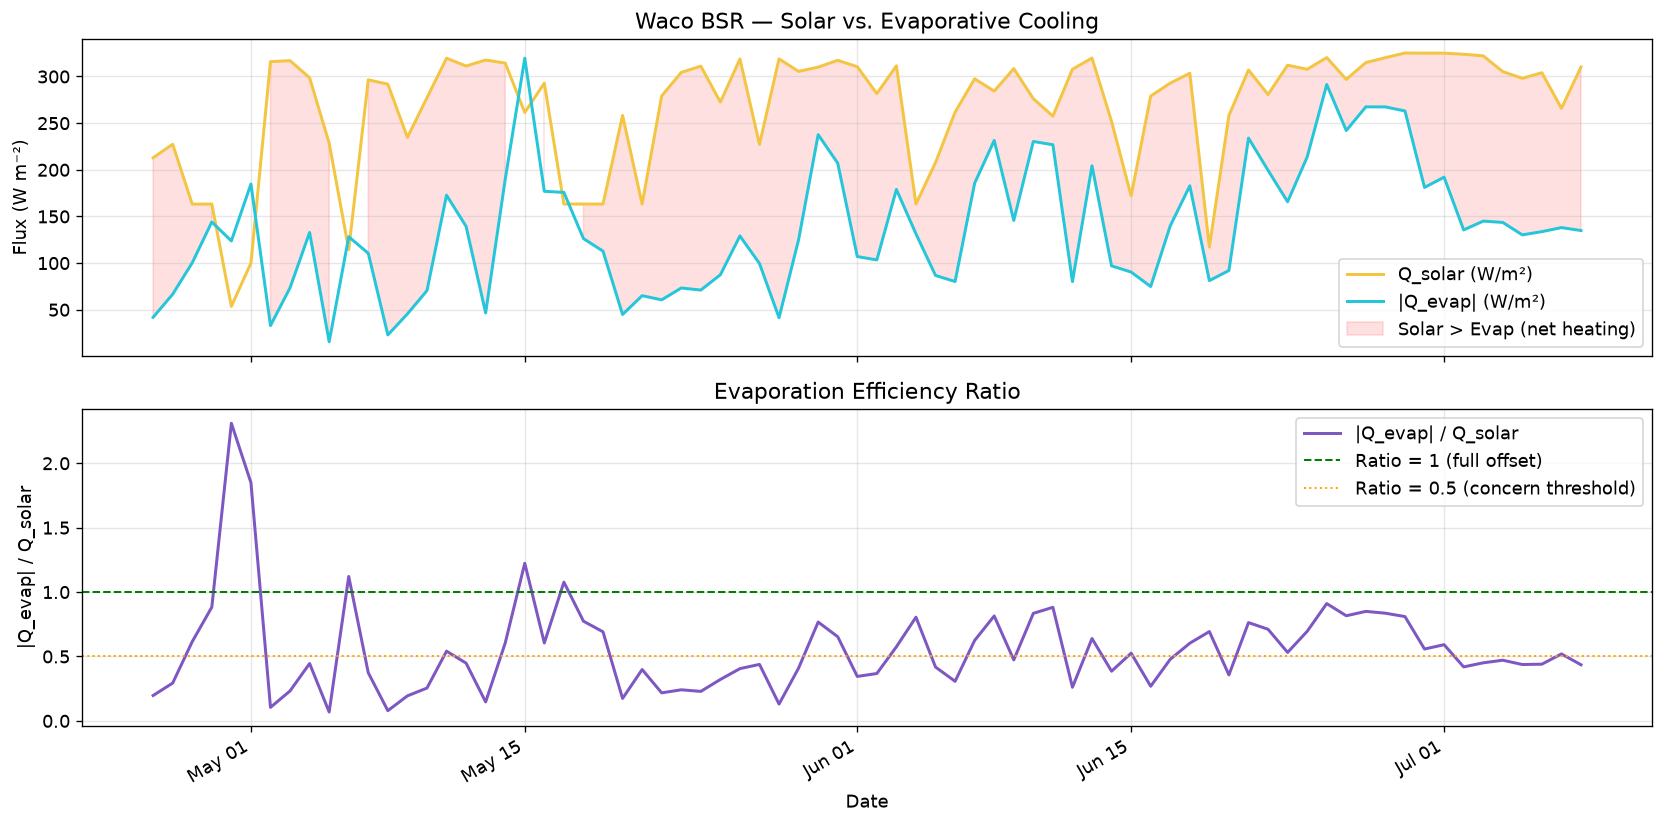

Mean |Q_evap|/Q_solar ratio: 0.559
Days where ratio < 0.5:      38


In [8]:
if not valid_dates.size:
    print('No heat_fluxes data available — skipping Plot 5.')
else:
    q_solar_arr = np.array(flux_data['Q_solar_Wm2'])
    q_evap_arr  = np.array(flux_data['Q_evap_Wm2'])

    # Ratio of evaporative cooling to solar input (both positive)
    ratio = np.abs(q_evap_arr) / np.where(q_solar_arr > 0.1, q_solar_arr, np.nan)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax1.plot(valid_dates, q_solar_arr, color='#f4c542', linewidth=1.8, label='Q_solar (W/m²)')
    ax1.plot(valid_dates, -q_evap_arr, color='#26c6da', linewidth=1.8, label='|Q_evap| (W/m²)')
    ax1.fill_between(valid_dates, q_solar_arr, -q_evap_arr,
                     where=(q_solar_arr > -q_evap_arr),
                     color='red', alpha=0.12, label='Solar > Evap (net heating)')
    ax1.set_ylabel('Flux (W m⁻²)')
    ax1.set_title('Waco BSR — Solar vs. Evaporative Cooling')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(valid_dates, ratio, color='#7e57c2', linewidth=1.8, label='|Q_evap| / Q_solar')
    ax2.axhline(1.0, color='green', linestyle='--', linewidth=1.2, label='Ratio = 1 (full offset)')
    ax2.axhline(0.5, color='orange', linestyle=':', linewidth=1.2, label='Ratio = 0.5 (concern threshold)')
    ax2.set_ylabel('|Q_evap| / Q_solar')
    ax2.set_xlabel('Date')
    ax2.set_title('Evaporation Efficiency Ratio')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    print(f'Mean |Q_evap|/Q_solar ratio: {np.nanmean(ratio):.3f}')
    print(f'Days where ratio < 0.5:      {(ratio < 0.5).sum()}')

## Summary & Fix Recommendations

Use the cells below to print a summary of findings and determine the parameter fix.

In [9]:
print('=== Waco BSR Thermal Model Bias Summary ===')
print(f'Total forecast days analyzed:  {len(dates)}')
print(f'Days exceeding 91°F cap:       {(pool_F > REAL_MAX_F).sum()} ({100*(pool_F > REAL_MAX_F).mean():.0f}%)')
print(f'Mean predicted pool temp:      {pool_F.mean():.1f}°F')
print(f'Max predicted pool temp:       {pool_F.max():.1f}°F')
print(f'Mean air temp (these days):    {air_F.mean():.1f}°F')
print()

# Sensitivity: what evap_coeff_mult brings steady-state to ≤91°F at 105°F air?
print('--- Sensitivity: EVAP_COEFF multiplier needed to reach ≤91°F ---')
for m in np.arange(1.0, 3.5, 0.1):
    ss = steady_state_F(evap_coeff_mult=m)
    if ss <= REAL_MAX_F:
        print(f'  EVAP_COEFF × {m:.1f} → {ss:.1f}°F  ← first value at or below cap')
        EVAP_BASE_VAL = 1.2 * 1.3e-3 * L_VAP * 0.622 / 101.325
        print(f'  Corresponds to EVAP_COEFF = {EVAP_BASE_VAL * m:.1f} W m⁻² (m/s)⁻¹ kPa⁻¹  (current: {EVAP_BASE_VAL:.1f})')
        break
else:
    print('  EVAP_COEFF alone cannot bring pool below 91°F — check other parameters.')

print()
print('Files to modify:')
print('  scripts/pull_api_data.py')
print('    Line ~485: EVAP_COEFF = 1.2 * 1.3e-3 * L_VAP * 0.622 / 101.325  (currently ~23.5)')
print('    Line ~48:  Waco ground_temp_C = 20.0')
print('    Line ~1215: SOLAR_FALLBACK_MJM2 = 15.0')

=== Waco BSR Thermal Model Bias Summary ===
Total forecast days analyzed:  94
Days exceeding 91°F cap:       25 (27%)
Mean predicted pool temp:      98.9°F
Max predicted pool temp:       173.3°F
Mean air temp (these days):    95.1°F

--- Sensitivity: EVAP_COEFF multiplier needed to reach ≤91°F ---
  EVAP_COEFF × 1.8 → 90.7°F  ← first value at or below cap
  Corresponds to EVAP_COEFF = 42.2 W m⁻² (m/s)⁻¹ kPa⁻¹  (current: 23.5)

Files to modify:
  scripts/pull_api_data.py
    Line ~485: EVAP_COEFF = 1.2 * 1.3e-3 * L_VAP * 0.622 / 101.325  (currently ~23.5)
    Line ~48:  Waco ground_temp_C = 20.0
    Line ~1215: SOLAR_FALLBACK_MJM2 = 15.0
